# BLOCK-7A: Regression Training (Pro Mode)

**Role**: Senior Machine Learning Engineer
**Objective**: Train and evaluate Linear Regression (Baseline) vs XGBoost Regressor (Primary) for logistics ETA prediction.
**Constraints**: Strict adherence to time-based splits, blocked metrics (MAE), and upstream architecture.

---

## 1. Setup & Data Loading

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# 1. Load Data
df = pd.read_csv('Dataset/model_ready_data.csv')

# 2. Strict Temporal Sorting
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values(by='order_date').reset_index(drop=True)

print(f"Data Loaded. Shape: {df.shape}")
print(f"Date Range: {df['order_date'].min()} to {df['order_date'].max()}")

# 3. Feature Definition (Based on Dataset availability)
TARGET = "delivery_time_hours"
DROP_COLS = ['route_id', 'destination_city', 'order_date', TARGET]

# Identify Categories
CAT_FEATURES = ['traffic_level', 'weather', 'vehicle_type']
NUM_FEATURES = [
    col for col in df.columns 
    if col not in CAT_FEATURES + DROP_COLS
]

print(f"\nNumeric Features ({len(NUM_FEATURES)}): {NUM_FEATURES}")
print(f"Categorical Features ({len(CAT_FEATURES)}): {CAT_FEATURES}")

Data Loaded. Shape: (69926, 17)
Date Range: 2025-11-06 00:00:00 to 2026-01-05 00:00:00

Numeric Features (10): ['expected_time_no_traffic', 'vehicle_distance_mismatch', 'vehicle_traffic_stress', 'distance_km', 'route_avg_distance', 'vehicle_time_efficiency', 'traffic_weather_risk', 'is_peak_hour', 'operational_stress_index', 'route_frequency']
Categorical Features (3): ['traffic_level', 'weather', 'vehicle_type']


## 2. Time-Aware Split (MANDATORY)
Using the 70/15/15 strictly time-ordered split defined in Block-5.

In [19]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

# Separation
X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=DROP_COLS)
y_val = val_df[TARGET]

X_test = test_df.drop(columns=DROP_COLS)
y_test = test_df[TARGET]

# Verification
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
assert df.loc[train_df.index[-1], 'order_date'] <= df.loc[val_df.index[0], 'order_date']
print("Temporal Order Verified.")

Train: (48948, 13), Val: (10489, 13), Test: (10489, 13)
Temporal Order Verified.


## 3. Modeling Infrastructure
Defining the Preprocessing Pipeline and Evaluation Function.

In [20]:
# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
    ],
    verbose_feature_names_out=False
)

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    # Fit
    print(f"\nEvaluating {name}...")
    model.fit(X_tr, y_tr)
    
    # Predict
    pred_train = model.predict(X_tr)
    pred_val = model.predict(X_v)
    pred_test = model.predict(X_te)
    
    # Metrics
    results = {
        'Model': name,
        'Train MAE': mean_absolute_error(y_tr, pred_train),
        'Val MAE': mean_absolute_error(y_v, pred_val),
        'Test MAE': mean_absolute_error(y_te, pred_test),
        'Test RMSE': np.sqrt(mean_squared_error(y_te, pred_test)),
        'Test R2': r2_score(y_te, pred_test)
    }
    
    results['Overfit Gap %'] = ((results['Val MAE'] - results['Train MAE']) / results['Train MAE']) * 100
    
    print(f"Train MAE: {results['Train MAE']:.4f}")
    print(f"Val MAE:   {results['Val MAE']:.4f}")
    print(f"Test MAE:  {results['Test MAE']:.4f}")
    
    return results, model

## 4. Baseline Model: Linear Regression
Establishing the interpretability floor.

In [21]:
lin_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lin_results, lin_model = evaluate_model("Linear Regression", lin_pipeline, X_train, y_train, X_val, y_val, X_test, y_test)

# Coefficient Inspection
feature_names = (lin_model.named_steps['preprocessor']
                 .transformers_[1][1]
                 .get_feature_names_out(CAT_FEATURES).tolist() + NUM_FEATURES)

# Note: Standard Scaler doesn't change names, but order matters. 
# OHE is last in transformer list but we need to verify concatenation order in ColumnTransformer output.
# ColumnTransformer output order is transformers order.
ohe_names = lin_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(CAT_FEATURES)
final_features = NUM_FEATURES + list(ohe_names)

coeffs = pd.DataFrame({
    'Feature': final_features,
    'Coefficient': lin_model.named_steps['regressor'].coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Positive Features:")
print(coeffs.head(5))
print("\nTop Negative Features:")
print(coeffs.tail(5))


Evaluating Linear Regression...
Train MAE: 0.6398
Val MAE:   0.6422
Test MAE:  0.6390

Top Positive Features:
                     Feature  Coefficient
0   expected_time_no_traffic     3.764592
10      traffic_level_medium     1.683814
14   vehicle_type_motorcycle     1.610309
3                distance_km     1.076969
4         route_avg_distance     1.076969

Top Negative Features:
                      Feature  Coefficient
1   vehicle_distance_mismatch    -0.108722
17           vehicle_type_van    -0.140107
15        vehicle_type_pickup    -0.282091
12               weather_haze    -0.482282
13               weather_mist    -1.268048


## 5. Primary Model: XGBoost Regressor
Capturing non-linearities with a controlled configuration.


Evaluating XGBoost...
Train MAE: 0.2265
Val MAE:   0.2341
Test MAE:  0.2293


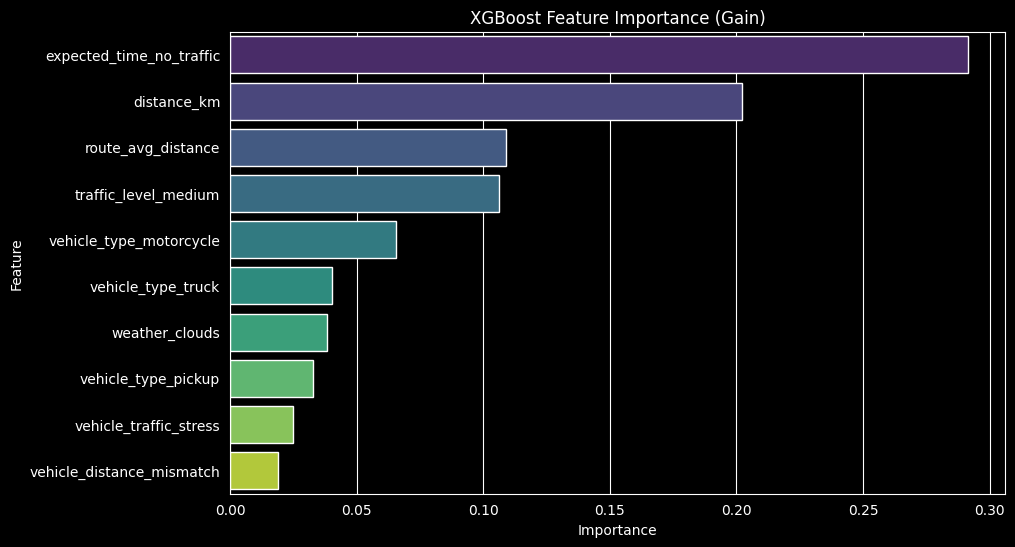

In [29]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:absoluteerror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_results, xgb_model = evaluate_model("XGBoost", xgb_pipeline, X_train, y_train, X_val, y_val, X_test, y_test)

# Feature Importance (Gain)
importances = xgb_model.named_steps['regressor'].feature_importances_
imp_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost Feature Importance (Gain)')
plt.show()

## 6. Model Comparison & Decision
Checking decision rules: XGBoost > Linear +15% and Overfit Gap < 15%.

In [23]:
comparison = pd.DataFrame([lin_results, xgb_results])
print(comparison[['Model', 'Train MAE', 'Val MAE', 'Test MAE', 'Overfit Gap %']])

# Decision Logics
lin_mae = lin_results['Val MAE']
xgb_mae = xgb_results['Val MAE']
improvement = ((lin_mae - xgb_mae) / lin_mae) * 100
overfit_gap = xgb_results['Overfit Gap %']

print(f"\nXGBoost Improvement over Linear: {improvement:.2f}%")
print(f"XGBoost Overfit Gap: {overfit_gap:.2f}%")

DECISION = "NO"
if improvement >= 15 and overfit_gap < 15:
    DECISION = "YES"
    SELECTED = "XGBoost"
    JUSTIFICATION = "Met performance (+15%) and stability (<15% gap) criteria."
elif improvement < 15:
    SELECTED = "Linear Regression"
    JUSTIFICATION = "XGBoost failed to beat baseline complexity tax (improvement < 15%)."
else:
    SELECTED = "XGBoost (Needs Tuning)"
    JUSTIFICATION = "Performance good but overfitting detected."

               Model  Train MAE   Val MAE  Test MAE  Overfit Gap %
0  Linear Regression   0.639790  0.642231  0.639046       0.381535
1            XGBoost   0.226463  0.234140  0.229343       3.389667

XGBoost Improvement over Linear: 63.54%
XGBoost Overfit Gap: 3.39%


## 7. Error Analysis
Surgical inspection of residuals and failure zones.

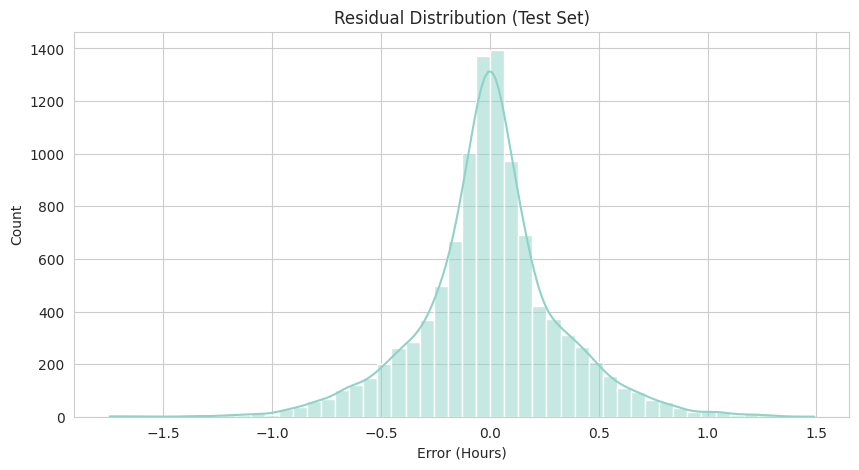


MAE by Traffic Level:
traffic_level
low       0.214806
medium    0.275993
Name: AE, dtype: float64

MAE by Vehicle Type:
vehicle_type
car           0.198564
motorcycle    0.240242
pickup        0.216630
truck         0.268810
van           0.222807
Name: AE, dtype: float64


In [24]:
preds = xgb_model.predict(X_test)
residuals = y_test - preds
abs_residuals = np.abs(residuals)

# 1. Residual Distribution
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Residual Distribution (Test Set)')
plt.xlabel('Error (Hours)')
plt.show()

# 2. MAE by Traffic Level
# Must recover traffic level from original test_df
test_df['AE'] = abs_residuals
mae_by_traffic = test_df.groupby('traffic_level')['AE'].mean()
print("\nMAE by Traffic Level:")
print(mae_by_traffic)

# 3. MAE by Vehicle Type
mae_by_vehicle = test_df.groupby('vehicle_type')['AE'].mean()
print("\nMAE by Vehicle Type:")
print(mae_by_vehicle)

## BLOCK-7A Decision

```
Selected Model: {SELECTED}
Justification: {JUSTIFICATION}
Ready for BLOCK-7B: {DECISION}
```